In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# plotting settings
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [2]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import summary

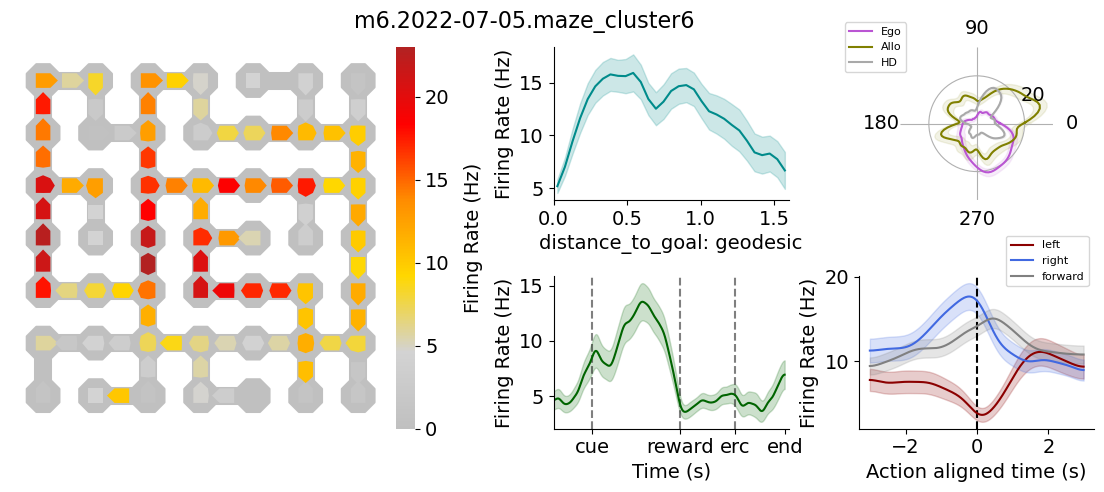

In [12]:
reload(summary)
Cluster = gc.get_cluster("m6.2022-07-05.maze_cluster6")
fig = summary.plot_tuning_summary_concise(Cluster)
fig.savefig("../results/nbeGLM/figures/cluster_tuning_summary.pdf")

In [3]:
from GridMaze.analysis.nbeGLM import load_model_sets as lms
from GridMaze.analysis.nbeGLM import model_comparisons as mc

# model performance validation

baseline vs embedding:
                                       feature_group model_type     t_stat  \
0                                    place_direction  baseline2   7.860563   
1                                    place_direction   baseline  11.438858   
2                   place_direction_distance_to_goal  baseline2   8.374015   
3                   place_direction_distance_to_goal   baseline  11.187852   
4  place_direction_distance_to_goal_egocentric_ac...  baseline2   7.449495   
5  place_direction_distance_to_goal_egocentric_ac...   baseline  11.614271   
6                                              place   baseline   5.637511   

      p_val  p_val_corr  
0  0.000535    0.000749  
1  0.000089    0.000232  
2  0.000398    0.000696  
3  0.000100    0.000232  
4  0.000688    0.000802  
5  0.000083    0.000232  
6  0.002435    0.002435  


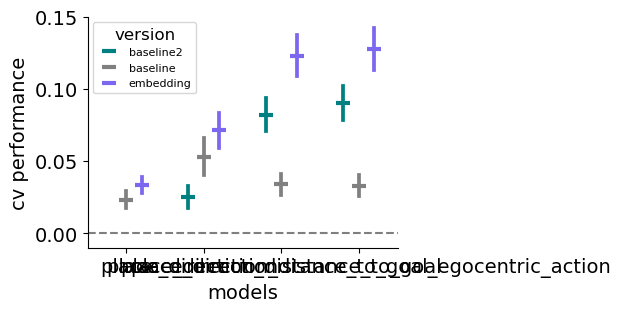

In [4]:
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, ax = plt.subplots(figsize=(4, 3))
mc.plot_performance_validation(nbe_validation, ax=ax, outlier_threshold=-0.2)
ax.set_ylim(-0.01, 0.15)
f.savefig("../results/nbeGLM/figures/performance_validation.pdf")

# feature-group interactions validation

In [5]:
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

place_direction_linear vs place_direction_nonlinear
t_stat: -5.41757241601617, p_val: 0.0029007774997038224
place_direction_distance_to_goal_linear vs place_direction_distance_to_goal_nonlinear
t_stat: 1.5168111792901828, p_val: 0.18976055641126255


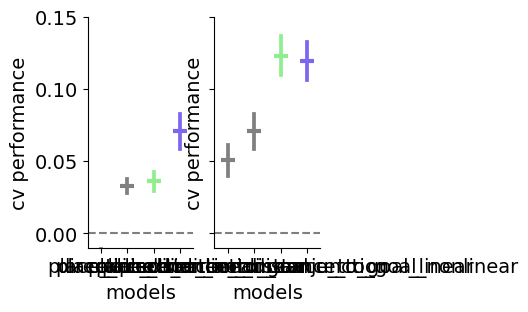

In [6]:
reload(mc)
f, axes = plt.subplots(1, 2, figsize=(3, 3), sharey=True)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_linear", "place_direction_nonlinear"],
    ax=axes[0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_linear",
        "place_direction_distance_to_goal_nonlinear",
    ],
    ax=axes[1],
)
axes[0].set_ylim(-0.01, 0.15)
f.savefig("../results/nbeGLM/figures/interaction_validation.pdf")

# unique variance explained

In [7]:
from GridMaze.analysis.nbeGLM import variance_explained as ve

In [8]:
variance_explained_results = lms.load_model_set_cv_scores(
    "variance_explained", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
    "remove_egocentric_action_all",
]
cpd_df = ve.get_cpd_df(variance_explained_results, reduced_models=reduced_models, outlier_threshold=-0.2)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results, reduced_models=reduced_models)

                 feature    t_stat     p_val  p_val_corr
0       distance_to_goal  4.504625  0.003186    0.003186
1  egocentric_action_all  5.207129  0.001723    0.002631
2        place_direction  5.185750  0.001754    0.002631


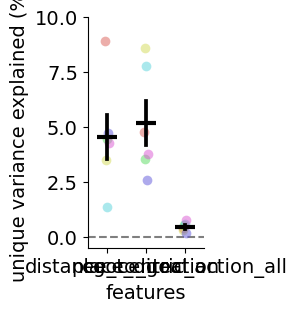

In [9]:
models = [f.split("_", 1)[-1] for f in reduced_models]
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(
    cpd_df, features=models, plot_single_subject=True, print_stats=True, orientation="vertical", ax=ax
)
ax.set_ylim(-0.5, 10)
f.savefig("../results/nbeGLM/figures/unique_variance_explained.pdf")

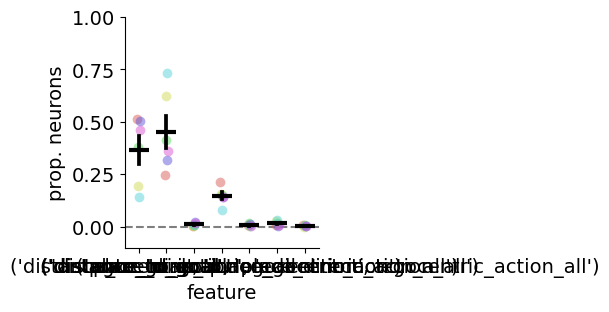

In [10]:
reload(ve)
f, ax = plt.subplots(figsize=(2.5, 3))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=models,
    ax=ax,
)
ax.set_ylim(-0.1, 1)
f.savefig("../results/nbeGLM/figures/feature_tuning_summary.pdf")

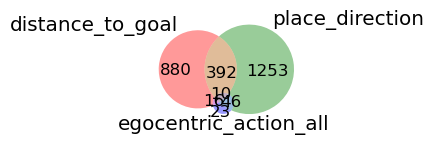

In [11]:
reload(ve)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=models,
    ax=ax,
)
fig.savefig("../results/nbeGLM/figures/feature_tuning_venn.pdf")

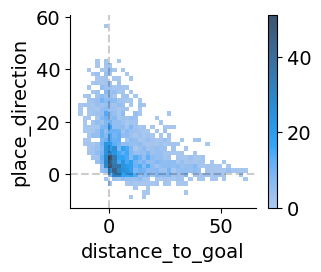

In [28]:
reload(ve)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
ve.plot_cpd_clusters(cpd_df, feature_tuned_df, ax=ax)
f.savefig("../results/nbeGLM/figures/cpd_scatter.pdf")

unique variance explained with more input features

In [13]:
variance_explained_full_results = lms.load_model_set_cv_scores(
    "variance_explained_full",
    maze_names=[
        "maze_1",
        "maze_2",
        "rooms_maze",
    ],
    all_completed=True,
)
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
    "remove_egocentric_action_free_forced",
    "remove_egocentric_action_action",
    "remove_goal",
    "remove_allocentric_angle_to_goal",
    "remove_egocentric_angle_to_goal",
    "remove_head_direction",
    "remove_speed",
    "remove_acceleration",
]
cpd_full_df = ve.get_cpd_df(variance_explained_full_results, reduced_models=reduced_models, outlier_threshold=-0.2)

                         feature    t_stat     p_val  p_val_corr
0                   acceleration  0.890637  0.206961    0.344935
1      allocentric_angle_to_goal  1.810739  0.064974    0.129949
2               distance_to_goal  2.619100  0.023574    0.058936
3       egocentric_action_action  0.307488  0.385434    0.481792
4  egocentric_action_free_forced  0.388518  0.356813    0.481792
5       egocentric_angle_to_goal -0.534925  0.692187    0.769097
6                           goal -6.107089  0.999147    0.999147
7                 head_direction  6.011604  0.000915    0.003050
8                place_direction  6.138534  0.000833    0.003050
9                          speed  7.022714  0.000452    0.003050


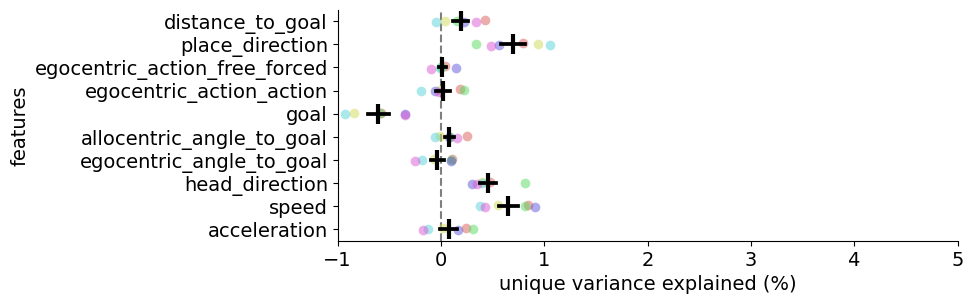

In [14]:
reload(ve)
f, ax = plt.subplots(figsize=(8, 3))
ve.plot_variance_explained(
    cpd_full_df,
    features=[f.split("_", 1)[-1] for f in reduced_models],
    print_stats=True,
    plot_single_subject=True,
    orientation="horizontal",
    ax=ax,
)
ax.set_xlim(-1, 5)
f.savefig("../results/nbeGLM/figures/unique_variance_explained_control_1.pdf")

In [16]:
reduced_models2 = [
    "remove_distance_to_goal_place_direction",
    "remove_distance_to_goal_egocentric_action_free_forced",
    "remove_distance_to_goal_egocentric_action_action",
    "remove_distance_to_goal_goal",
    "remove_distance_to_goal_allocentric_angle_to_goal",
    "remove_distance_to_goal_egocentric_angle_to_goal",
    "remove_distance_to_goal_head_direction",
    "remove_distance_to_goal_speed",
    "remove_distance_to_goal_acceleration",
]
cpd_full_df2 = ve.get_cpd_df(variance_explained_full_results, reduced_models=reduced_models2, outlier_threshold=-0.2)

                                          feature    t_stat     p_val  \
0                   distance_to_goal_acceleration  1.016076  0.178105   
1      distance_to_goal_allocentric_angle_to_goal  1.089655  0.162786   
2       distance_to_goal_egocentric_action_action  0.629683  0.278275   
3  distance_to_goal_egocentric_action_free_forced  1.535182  0.092666   
4       distance_to_goal_egocentric_angle_to_goal  0.004060  0.498459   
5                           distance_to_goal_goal  1.351639  0.117210   
6                 distance_to_goal_head_direction  7.954974  0.000253   
7                distance_to_goal_place_direction  7.937196  0.000256   
8                          distance_to_goal_speed  4.820273  0.002399   

   p_val_corr  
0    0.228993  
1    0.228993  
2    0.313060  
3    0.208498  
4    0.498459  
5    0.210978  
6    0.001151  
7    0.001151  
8    0.007196  


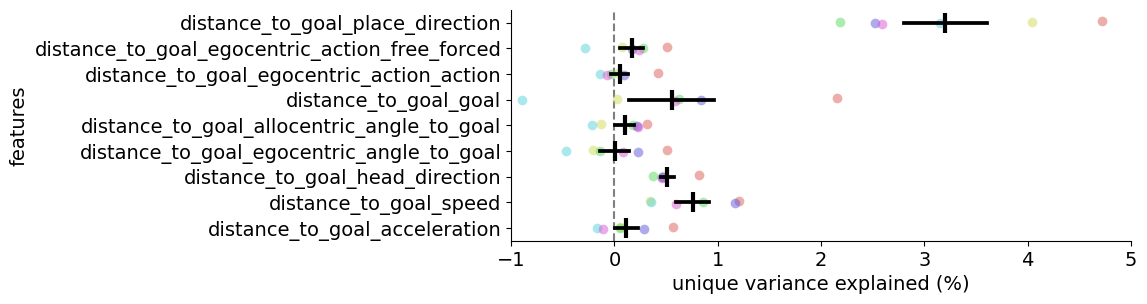

In [17]:
reload(ve)
f, ax = plt.subplots(figsize=(8, 3))
ve.plot_variance_explained(
    cpd_full_df2,
    features=[f.split("_", 1)[-1] for f in reduced_models2],
    print_stats=True,
    plot_single_subject=True,
    orientation="horizontal",
    ax=ax,
)
ax.set_xlim(-1, 5)
f.savefig("../results/nbeGLM/figures/unique_variance_explained_control_2.pdf")

In [19]:
variance_explained_partitioned_results = lms.load_model_set_cv_scores(
    "variance_explained_full_partitioned",
    maze_names=[
        "maze_1",
        "maze_2",
        "rooms_maze",
    ],
    all_completed=True,
)
reduced_models3 = [
    "remove_distance_to_goal",
    "remove_place_direction",
    "remove_egocentric_action_free_forced",
    "remove_egocentric_action_action",
    "remove_goal",
    "remove_allocentric_angle_to_goal",
    "remove_egocentric_angle_to_goal",
    "remove_head_direction",
    "remove_speed",
    "remove_acceleration",
]
cpd_full_df3 = ve.get_cpd_df(
    variance_explained_partitioned_results, reduced_models=reduced_models3, outlier_threshold=-0.2
)

                         feature    t_stat     p_val  p_val_corr
0                   acceleration  1.487868  0.098474    0.196948
1      allocentric_angle_to_goal  0.327679  0.378215    0.472769
2               distance_to_goal  4.126397  0.004558    0.011396
3       egocentric_action_action  4.734471  0.002588    0.008626
4  egocentric_action_free_forced  0.450036  0.335762    0.472769
5       egocentric_angle_to_goal -1.757237  0.930391    0.995151
6                           goal -4.063247  0.995151    0.995151
7                 head_direction  0.468006  0.329736    0.472769
8                place_direction  6.601176  0.000600    0.002998
9                          speed  7.744555  0.000287    0.002869


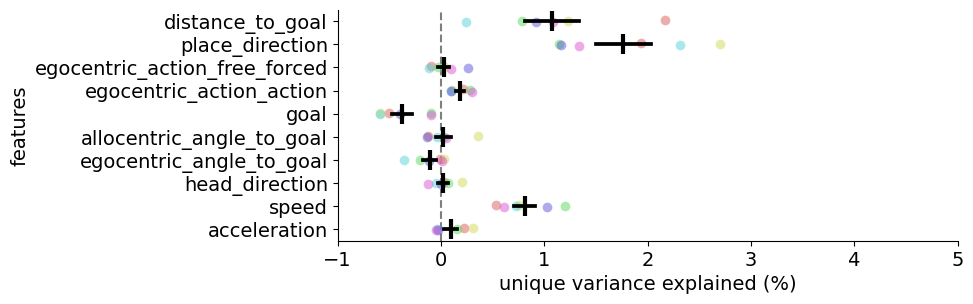

In [20]:
reload(ve)
f, ax = plt.subplots(figsize=(8, 3))
ve.plot_variance_explained(
    cpd_full_df3,
    features=[f.split("_", 1)[-1] for f in reduced_models3],
    print_stats=True,
    plot_single_subject=True,
    orientation="horizontal",
    ax=ax,
)
ax.set_xlim(-1, 5)
f.savefig("../results/nbeGLM/figures/unique_variance_explained_control_3.pdf")

# main feature interactions 

In [22]:
main_feature_interactions = lms.load_model_set_cv_scores(
    "main_feature_interactions",
    maze_names=["maze_1", "maze_2", "rooms_maze"],
    all_completed=True,
)

                                             model_1  \
0  place-direction-distance_to_goal-egocentric_ac...   
1  place-direction-distance_to_goal-egocentric_ac...   
2  place.direction-distance_to_goal-egocentric_ac...   

                                             model_2    t_stat     p_val  \
0  place.direction-distance_to_goal-egocentric_ac... -4.415453  0.006921   
1  place.direction.distance_to_goal.egocentric_ac... -4.926882  0.004371   
2  place.direction.distance_to_goal.egocentric_ac...  0.434662  0.681927   

   p_val_corr  
0    0.010382  
1    0.010382  
2    0.681927  


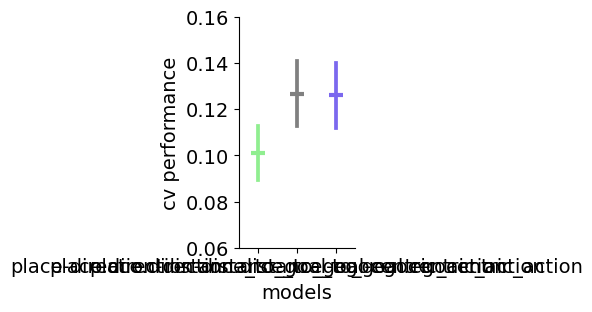

In [23]:
reload(mc)
f, ax = plt.subplots(figsize=(1.5, 3))
mc.plot_main_feature_interactions(main_feature_interactions, plot_single_subjects=False, outlier_threshold=-0.2, ax=ax)
ax.set_ylim(0.06, 0.16)
f.savefig("../results/nbeGLM/figures/main_feature_interactions.pdf")

# visualising embedding latent tuning

In [3]:
from GridMaze.maze import representations as mr
from GridMaze.analysis.nbeGLM import vis_latents as vl

In [4]:
reload(vl)
model_set = "full_models"
model_name = "full_model"
maze_name = "maze_2"
latent_tuning_dfs = vl.get_latent_tuning_dfs(model_set=model_set, model_name=model_name, maze_name=maze_name)
simple_maze = mr.get_simple_maze(maze_name)

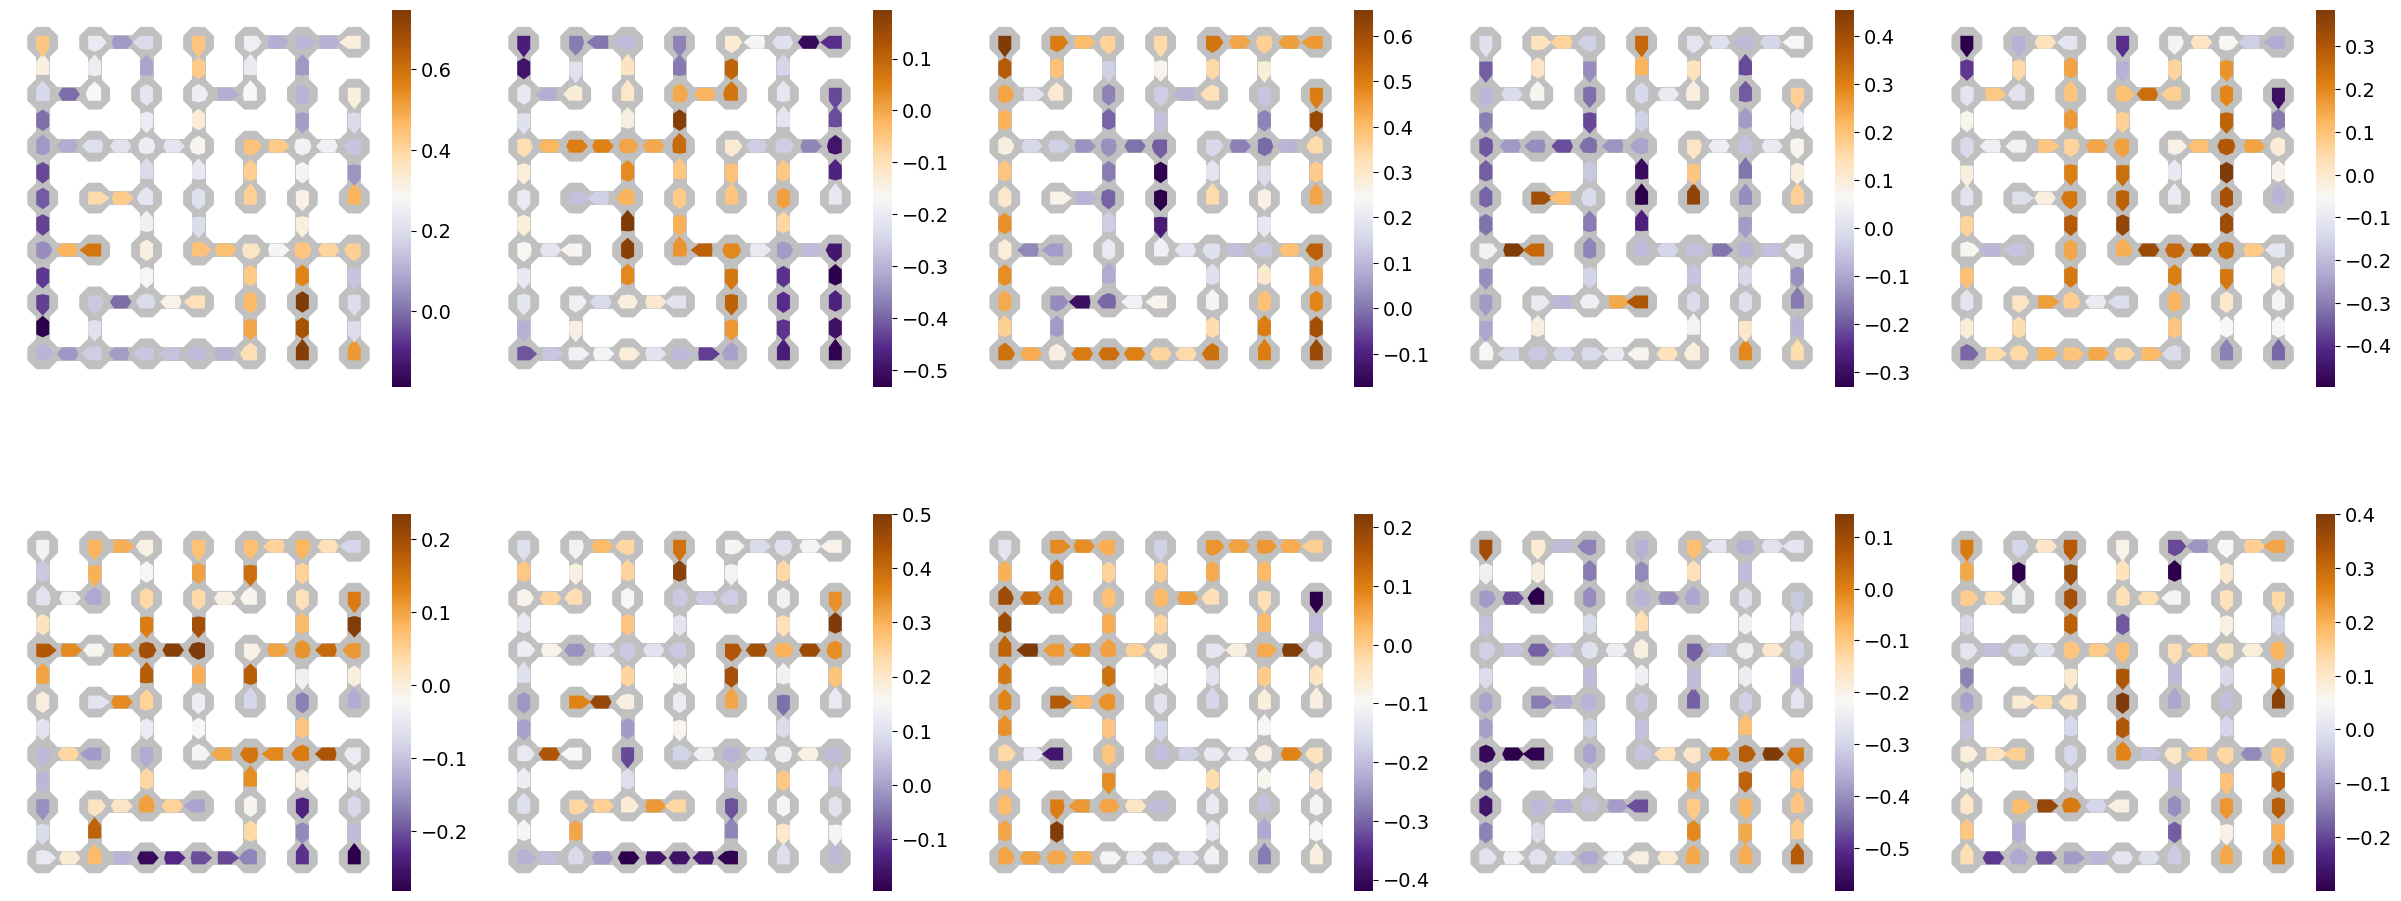

In [6]:
reload(vl)
f, axes = plt.subplots(2, 5, figsize=(30, 12))
vl.plot_latent_place_direction_tuning(latent_tuning_dfs["place_direction"], simple_maze, axes=axes)
f.savefig("../results/nbeGLM/figures/latent_place_direction_tuning.pdf")

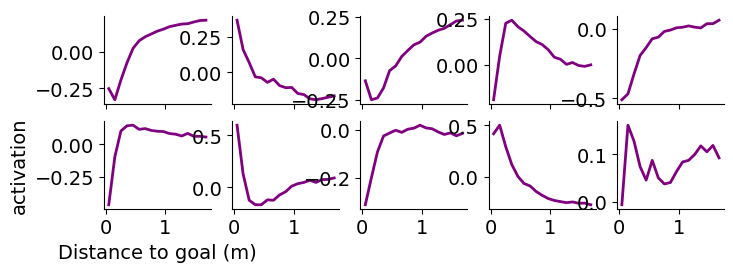

In [7]:
reload(vl)
f, axes = plt.subplots(2, 5, figsize=(8, 2.5), sharex=True)
vl.plot_latent_distance_to_goal_tuning(latent_tuning_dfs["distance_to_goal"], axes=axes)
f.savefig("../results/nbeGLM/figures/latent_distance_to_goal_tuning.pdf")

# population tuning summaries revisted

In [8]:
from GridMaze.analysis.nbeGLM import tuning_summaries as ts
from GridMaze.maze import representations as mr

In [9]:
# distance tuning
distance_tuning_df = ts.get_population_unique_distance_to_goal_tuning_df()

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


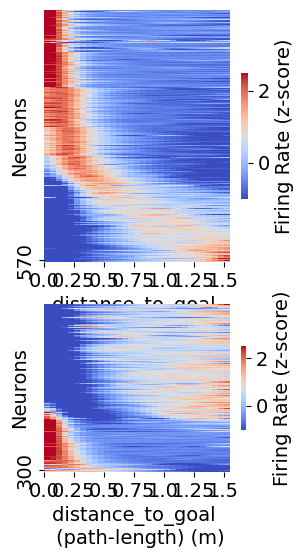

In [10]:
# plot
f, axes = plt.subplots(2, 1, figsize=(3, 6), height_ratios=[1.5, 1])
ts.plot_unique_distance_to_goal_tuning_heatmap(distance_tuning_df, axes=axes)
f.savefig("../results/nbeGLM/figures/unique_distance_tuning_heatmap.pdf")

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.placeDirectionTuningMetrics.parquet not found for m8.2022-07-26.maze


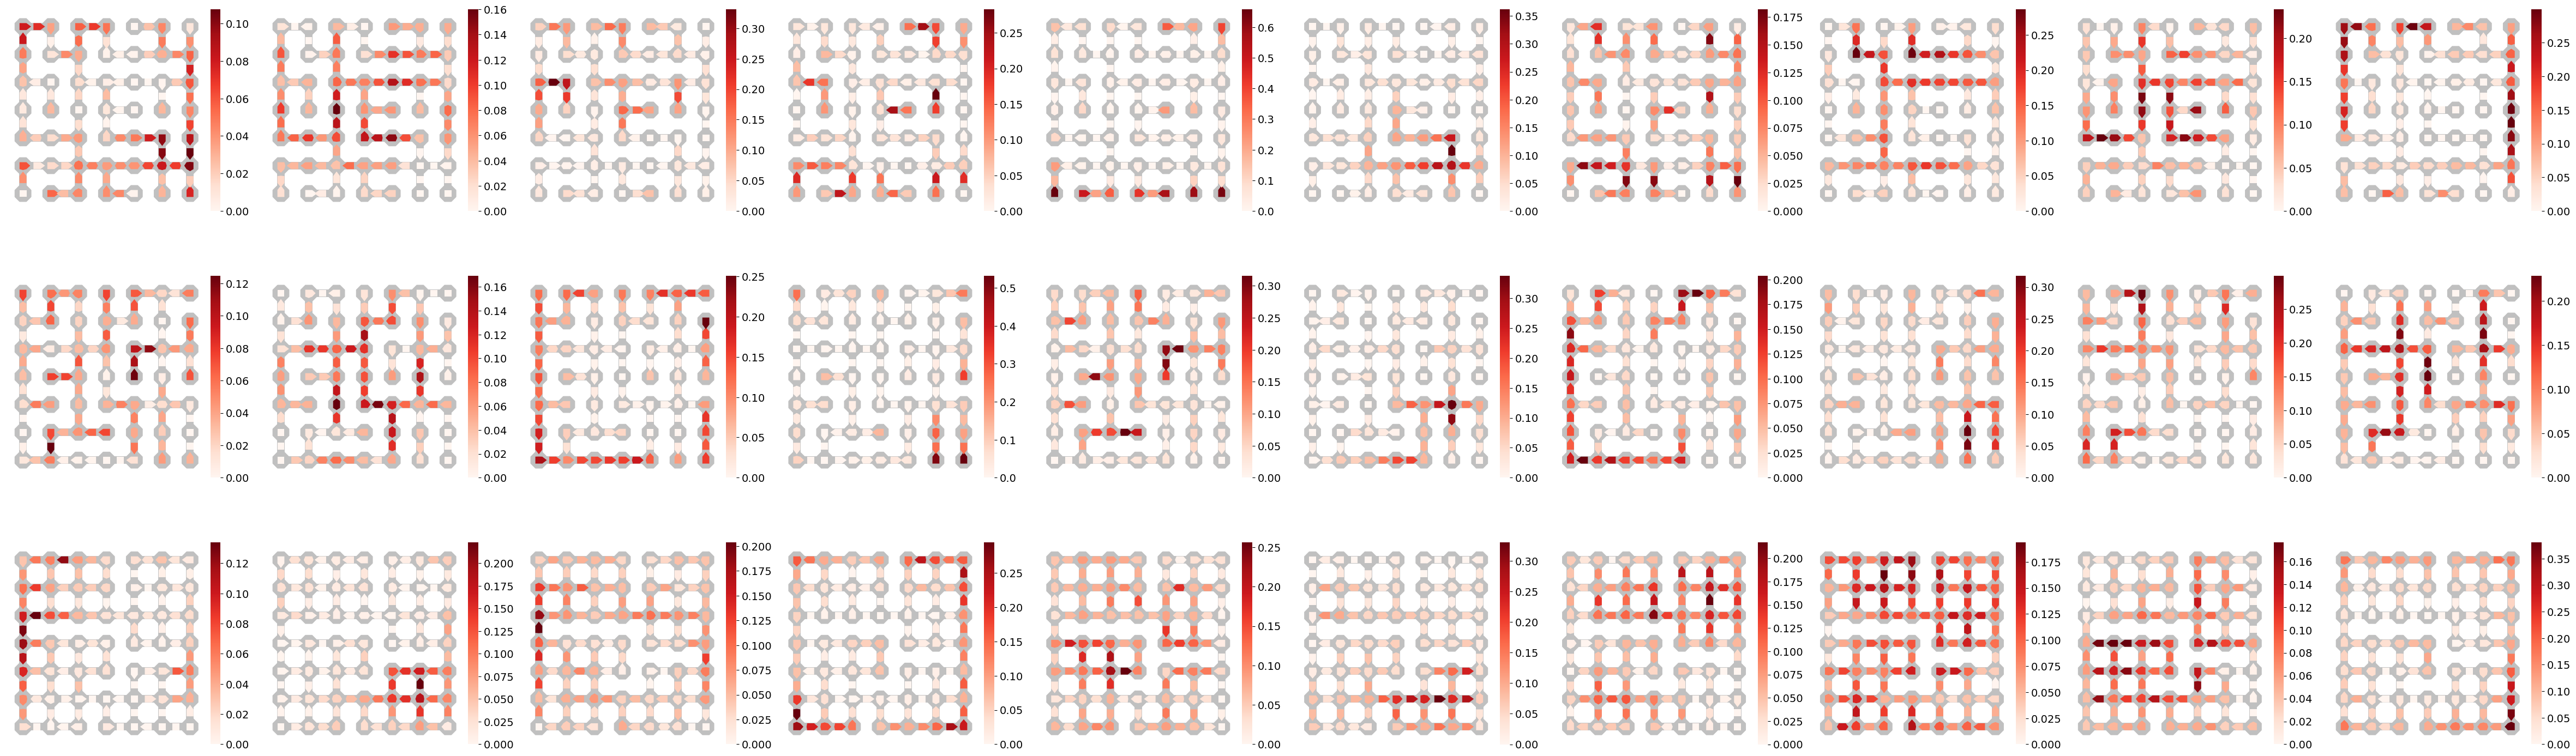

In [11]:
# place-direction tuning
dim_red = "nmf"
n_components = 10
f, axes = plt.subplots(3, n_components, figsize=(6 * n_components, 18))
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    simple_maze = mr.get_simple_maze(maze_name)
    place_direction_tuning_df = ts.get_population_unique_place_direction_tuning_df(maze_name=maze_name)
    ts.plot_unique_place_direction_components(
        place_direction_tuning_df, simple_maze, dim_red=dim_red, n_components=n_components, axes=axes[i, :]
    )
f.savefig(f"../results/nbeGLM/figures/unique_place_direction_{dim_red}_components.pdf")